In [3]:
from IPython.display import display, HTML

display(HTML("""
<div style="background: linear-gradient(135deg, #003049 0%, #023e8a 40%, #0077b6 70%, #00b4d8 100%);
            padding: 50px 40px; border-radius: 12px; text-align: center;
            font-family: Georgia, serif; box-shadow: 0 4px 20px rgba(0,0,0,0.3);">

  <span style="color: #90e0ef; font-weight: bold; font-size: 14px; letter-spacing: 2px;">
    CUC - COLEGIO UNIVERSITARIO DE CARTAGO
  </span>

  <hr style="border: 1px solid rgba(144,224,239,0.5); margin: 15px 0;">

  <h1 style="color: #caf0f8; font-size: 36px; margin: 20px 0 10px 0;
             text-shadow: 2px 2px 4px rgba(0,0,0,0.5); letter-spacing: 2px;">
    Prediccion del Consumo de Energia<br>en Costa Rica
  </h1>

  <h2 style="color: white; font-size: 20px; font-weight: normal; margin: 5px 0 25px 0;">
    Analisis Exploratorio de Datos (EDA)
  </h2>

  <hr style="border: 1px solid rgba(144,224,239,0.5); margin: 15px 0;">

  <p style="color: #90e0ef; font-weight: bold; font-size: 15px; margin: 8px 0;">
    Curso: <span style="color: white; font-weight: normal;">BD-143 Programacion II</span></p>
  <p style="color: #90e0ef; font-weight: bold; font-size: 15px; margin: 8px 0;">
    Profesor: <span style="color: white; font-weight: normal;">Osvaldo Gonzalez Chaves</span></p>
  <p style="color: #90e0ef; font-weight: bold; font-size: 15px; margin: 8px 0;">
    Proyecto: <span style="color: white; font-weight: normal;">Proyecto 5</span></p>
  <p style="color: #90e0ef; font-weight: bold; font-size: 15px; margin: 8px 0;">
    Cuatrimestre: <span style="color: white; font-weight: normal;">I Cuatrimestre 2026</span></p>

  <hr style="border: 1px solid rgba(144,224,239,0.5); margin: 20px 0 15px 0;">

  <p style="color: #90e0ef; font-size: 13px; letter-spacing: 2px; margin-bottom: 10px;">ELABORADO POR</p>
  <p style="color: white; font-size: 20px; font-weight: bold; margin: 5px 0;">Desmond, Luis Diego y Nadin</p>

</div>
"""))

In [2]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedMarkdown h1 {
  background: linear-gradient(135deg, #003049, #0077b6, #00b4d8);
  -webkit-background-clip: text;
  -webkit-text-fill-color: transparent;
  background-clip: text;
  font-family: Georgia, serif !important;
  font-size: 2em !important;
  border-bottom: 3px solid #0077b6 !important;
  padding-bottom: 8px !important;
}
.jp-RenderedMarkdown h2 {
  color: #0077b6 !important;
  font-family: Georgia, serif !important;
  border-left: 5px solid #00b4d8 !important;
  padding-left: 12px !important;
}
.jp-RenderedMarkdown h3 {
  color: #023e8a !important;
  border-bottom: 1px solid rgba(0,180,216,0.4) !important;
  padding-bottom: 4px !important;
}
</style>
"""))

# Prediccion del Consumo de Energia en Costa Rica — EDA

Este notebook realiza el analisis exploratorio del dataset final que combina datos de
precios medios de **ARESEP** con variables climaticas de **NASA POWER** por empresa
distribuidora, para el periodo 2020–2025.

El objetivo del EDA es comprender la estructura de los datos, detectar problemas de
calidad (nulos, outliers, valores atipicos) y extraer patrones que sirvan de base
para el modelo supervisado de prediccion de consumo electrico.

## 1. Importaciones y configuracion

Importamos las librerias necesarias para visualizacion y la clase `ProcesadorEDA`
del proyecto, que encapsula toda la logica de carga, limpieza y exploracion de datos.
Tambien configuramos el estilo global de los graficos.

In [10]:
import sys
sys.path.append('../..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.eda.ProcesadorEDA import ProcesadorEDA


plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

PALETA = ['#003049','#0077b6','#00b4d8','#e9c46a','#e76f51','#2a9d8f','#6a4c93','#f4a261','#264653']

print('Configuracion lista.')

Configuracion lista.


## 2. Carga del dataset

Cargamos el archivo `dataset_final_2020_2025.csv` que fue generado por el pipeline ETL
del proyecto. Este archivo ya integra los datos de ARESEP (ventas, ingresos, tarifas)
con las variables climaticas de NASA POWER (temperatura, viento, nubosidad, precipitacion)
por empresa y mes.

Usamos el metodo `csv_to_df()` de la clase `ProcesadorEDA`, que carga el archivo y
calcula automaticamente metricas basicas del dataset (filas, columnas, nulos, ceros).

In [11]:
eda = ProcesadorEDA()
params = eda.csv_to_df('../../data/processed/dataset_final_2020_2025.csv', chain=False)

print('=== Resumen del dataset ===')
for k, v in params.items():
    if k != 'Dataframe':
        print(f'  {k}: {v}')

df = eda.df
df.head()

=== Resumen del dataset ===
  Numero de filas: 4277
  Numero de columnas: 28
  Porcentaje de nulos: 1.8746451117271785
  Ceros totales: 0


,Mes,Año,Empresa,Tarifa,Abonados,Ventas,Ingreso sin CVG,Ingreso con CVG,Precio Medio sin CVG,Precio Medio con CVG,...,T2M_MIN,CLOUD_OD,GWETROOT,TS,PRECTOTCORR,ALLSKY_SFC_SW_DWN,PS,T2MWET,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_LW_DWN
0,12,2020,CNFL,ALUMBRADO PÚBLICO,NaN,6992121.03,4.343615e+08,4.343615e+08,62.12,62.12,...,16.960000,4.610000,0.910000,22.600000,6.780000,4.688933,93.720000,21.020000,1.590333,9.499333
1,12,2020,COOPEALFARORUIZ,ALUMBRADO PÚBLICO,NaN,40730.50,1.669136e+06,1.669136e+06,40.98,40.98,...,16.960000,6.050000,0.910000,22.600000,6.780000,3.957600,93.720000,21.020000,1.523800,9.360000
2,12,2020,COOPEGUANACASTE,ALUMBRADO PÚBLICO,NaN,714811.65,4.072282e+07,4.072282e+07,56.97,56.97,...,21.825000,4.500000,0.855000,25.925000,1.745000,5.116300,100.005000,24.335000,1.419800,9.559200
3,12,2020,COOPELESCA,ALUMBRADO PÚBLICO,NaN,790350.77,4.456738e+07,4.456738e+07,56.39,56.39,...,19.956667,5.663333,0.906667,24.136667,5.836667,4.006567,97.903333,22.883333,1.554600,9.484233
4,12,2020,COOPESANTOS,ALUMBRADO PÚBLICO,NaN,333997.00,2.057422e+07,2.057422e+07,61.60,61.60,...,16.120000,5.230000,0.960000,20.740000,11.020000,4.645300,90.070000,19.250000,1.619300,9.062600


## 3. Estructura y tipos de datos

Antes de analizar, revisamos la estructura del dataset: cuantas filas y columnas tiene,
que tipo de dato tiene cada columna, y cuales son los valores posibles de las variables
categoricas principales (empresa, tarifa, sistema).

Esto nos permite confirmar que los tipos son correctos y entender el alcance del dataset.

In [12]:
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print()

unicos = eda.col_uniques(['Empresa', 'Tarifa', 'Sistema'], chain=False)
for col, (cant, vals) in unicos.items():
    print(f'{col} ({cant} valores unicos):')
    for v in sorted(vals):
        print(f'   - {v}')
    print()

Filas: 4,277  |  Columnas: 28

Empresa (9 valores unicos):
   - CNFL
   - COOPEALFARORUIZ
   - COOPEGUANACASTE
   - COOPELESCA
   - COOPESANTOS
   - ESPH
   - ICE
   - JASEC
   - USUARIOS DIRECTOS

Tarifa (13 valores unicos):
   - ALUMBRADO PÚBLICO
   - COMERCIOS Y SERVICIOS
   - INDUSTRIAL
   - MEDIA TENSIÓN A
   - MEDIA TENSIÓN B
   - PREFERENCIAL
   - PROMOCIONAL
   - RESIDENCIAL
   - RESIDENCIAL HORARIA
   - RESIDENCIAL MODALIDAD PREPAGO
   - USUARIOS DIRECTOS
   - VENTAS A ICE DISTRIBUCIÓN Y A LA CNFL
   - VENTAS AL SERVICIO DE DISTRIBUCIÓN

Sistema (2 valores unicos):
   - Distribucion
   - Generacion



In [13]:
# Tipos de dato por columna
df.dtypes.to_frame('Tipo').T

,Mes,Año,Empresa,Tarifa,Abonados,Ventas,Ingreso sin CVG,Ingreso con CVG,Precio Medio sin CVG,Precio Medio con CVG,...,T2M_MIN,CLOUD_OD,GWETROOT,TS,PRECTOTCORR,ALLSKY_SFC_SW_DWN,PS,T2MWET,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_LW_DWN
Tipo,int64,int64,str,str,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


## 4. Resumen estadistico descriptivo

El resumen descriptivo muestra las medidas de tendencia central y dispersion
para las variables numericas del dataset. Analizamos las columnas mas relevantes
para el proyecto: ventas, ingresos, precio medio y las variables climaticas principales.

| Medida | Descripcion |
|--------|-------------|
| `count` | Valores no nulos |
| `mean` | Promedio aritmetico |
| `std` | Desviacion estandar |
| `min / max` | Valor minimo y maximo |
| `Q1 / Q3` | Percentiles 25 y 75 |
| `median` | Valor central de la distribucion |

In [14]:
cols_desc = ['Ventas', 'Ingreso con CVG', 'Precio Medio con CVG', 'T2M', 'WS10M', 'RH2M', 'PRECTOTCORR']

resumen = eda.res_descrip(cols_desc, chain=False)

# Agregar mediana al resumen estandar
mediana = df[cols_desc].median().rename('median')
resumen = pd.concat([resumen, mediana.to_frame().T])
resumen.round(2)

,Ventas,Ingreso con CVG,Precio Medio con CVG,T2M,WS10M,RH2M,PRECTOTCORR
count,4.275000e+03,4.275000e+03,4274.00,4205.00,4205.00,4205.00,4205.00
mean,2.876233e+07,1.958225e+09,5869.52,23.40,1.52,85.46,8.32
std,6.621515e+07,3.885168e+09,375403.83,2.15,0.83,6.71,6.38
min,1.000000e+00,2.897437e+04,25.09,18.99,0.60,60.22,0.05
25%,1.185725e+06,8.003645e+07,58.52,21.74,1.00,82.08,3.32
50%,6.729322e+06,5.114520e+08,75.55,23.25,1.28,87.60,7.52
75%,2.154265e+07,1.577872e+09,92.64,24.80,1.74,90.60,11.76
max,4.654363e+08,2.621318e+10,24542350.52,30.47,6.55,94.04,38.68
median,6.729322e+06,5.114520e+08,75.55,23.25,1.28,87.60,7.52


### Interpretacion del resumen descriptivo

**Ventas (kWh):**
- La media (28.7M kWh) es muy superior a la mediana (6.7M kWh), lo que indica
  una distribucion asimetrica hacia la derecha: pocas empresas grandes (ICE, CNFL)
  concentran la mayor parte de las ventas.
- La desviacion estandar alta confirma la gran disparidad entre empresas.

**Precio Medio con CVG (₡/kWh):**
- Existe variacion considerable entre tarifas: la residencial y alumbrado publico
  tienen precios distintos a la industrial o media tension.

**Variables climaticas:**
- La temperatura promedio (T2M) ronda los 23°C, coherente con el clima tropical de CR.
- La precipitacion (PRECTOTCORR) muestra alta variabilidad entre zonas geograficas.

## 5. Analisis de valores nulos

Identificamos las columnas con valores faltantes usando el metodo `col_nulls()` del
procesador. Ademas, reemplazamos el valor centinela **-999** que usa NASA POWER
para indicar datos no disponibles, ya que de lo contrario distorsionaria los analisis.

Detectar y entender los nulos es clave antes de entrenar cualquier modelo supervisado.

In [16]:

cols_clima = ['T2M','WS10M','CLOUD_AMT','RH2M','T2M_MAX','T2M_MIN',
              'CLOUD_OD','GWETROOT','TS','PRECTOTCORR',
              'ALLSKY_SFC_SW_DWN','PS','T2MWET','ALLSKY_SFC_SW_DIFF','ALLSKY_SFC_LW_DWN']
df[cols_clima] = df[cols_clima].replace(-999, float('nan'))
eda.df = df

nulos = eda.col_nulls(chain=False)
print('Columnas con valores nulos:')
for col, cant in nulos.items():
    pct = cant / len(df) * 100
    print(f'  {col}: {cant} nulos ({pct:.1f}%)')

Columnas con valores nulos:
  Abonados: 1153 nulos (27.0%)
  Ventas: 2 nulos (0.0%)
  Ingreso sin CVG: 2 nulos (0.0%)
  Ingreso con CVG: 2 nulos (0.0%)
  Precio Medio sin CVG: 3 nulos (0.1%)
  Precio Medio con CVG: 3 nulos (0.1%)
  T2M: 72 nulos (1.7%)
  WS10M: 72 nulos (1.7%)
  CLOUD_AMT: 133 nulos (3.1%)
  RH2M: 72 nulos (1.7%)
  T2M_MAX: 72 nulos (1.7%)
  T2M_MIN: 72 nulos (1.7%)
  CLOUD_OD: 133 nulos (3.1%)
  GWETROOT: 72 nulos (1.7%)
  TS: 72 nulos (1.7%)
  PRECTOTCORR: 72 nulos (1.7%)
  ALLSKY_SFC_SW_DWN: 133 nulos (3.1%)
  PS: 72 nulos (1.7%)
  T2MWET: 72 nulos (1.7%)
  ALLSKY_SFC_SW_DIFF: 133 nulos (3.1%)
  ALLSKY_SFC_LW_DWN: 133 nulos (3.1%)


### Grafico de nulos

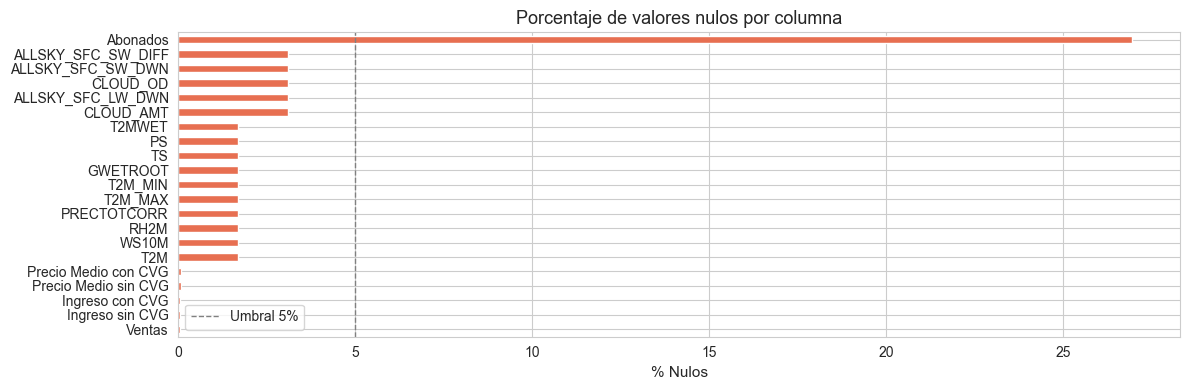

In [22]:

nulos_pct = pd.Series({col: cant/len(df)*100 for col, cant in nulos.items()})

fig, ax = plt.subplots(figsize=(12, 4))
nulos_pct.sort_values().plot(kind='barh', ax=ax, color='#e76f51', edgecolor='white')
ax.axvline(5, color='gray', linestyle='--', linewidth=1, label='Umbral 5%')
ax.set_title('Porcentaje de valores nulos por columna')
ax.set_xlabel('% Nulos')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretacion

Los nulos en variables climaticas (~1.7%) corresponden exclusivamente a la empresa
**USUARIOS DIRECTOS**, que no tiene coordenadas geograficas asignadas en el cliente
NASA POWER y por eso no recibio datos de clima.

Los nulos en `Abonados` (~27%) son esperados: no todas las tarifas registran
esta variable. Para el modelo de prediccion, esta columna podria excluirse o
imputarse segun la empresa.

## 6. Analisis de outliers

Utilizamos el metodo **IQR (Rango Intercuartilico)** para detectar outliers en las
variables numericas principales. Se considera outlier todo valor por debajo de
`Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR`.

Detectar outliers es importante porque pueden distorsionar los modelos de regresion
si no se tratan adecuadamente antes del entrenamiento.

In [ ]:
cols_outliers = ['Ventas', 'Ingreso con CVG', 'Precio Medio con CVG', 'T2M', 'PRECTOTCORR']
resultados = eda.detect_outliers(cols_outliers, chain=False)

print('=== Deteccion de Outliers (metodo IQR) ===')
for r in resultados:
    pct = r['cantidad'] / len(df) * 100
    print(f"\n  {r['columna']}")
    print(f"    Limite inferior : {r['limite_inf']:,.2f}")
    print(f"    Limite superior : {r['limite_sup']:,.2f}")
    print(f"    Outliers        : {r['cantidad']} ({pct:.1f}%)")

### Boxplots de outliers

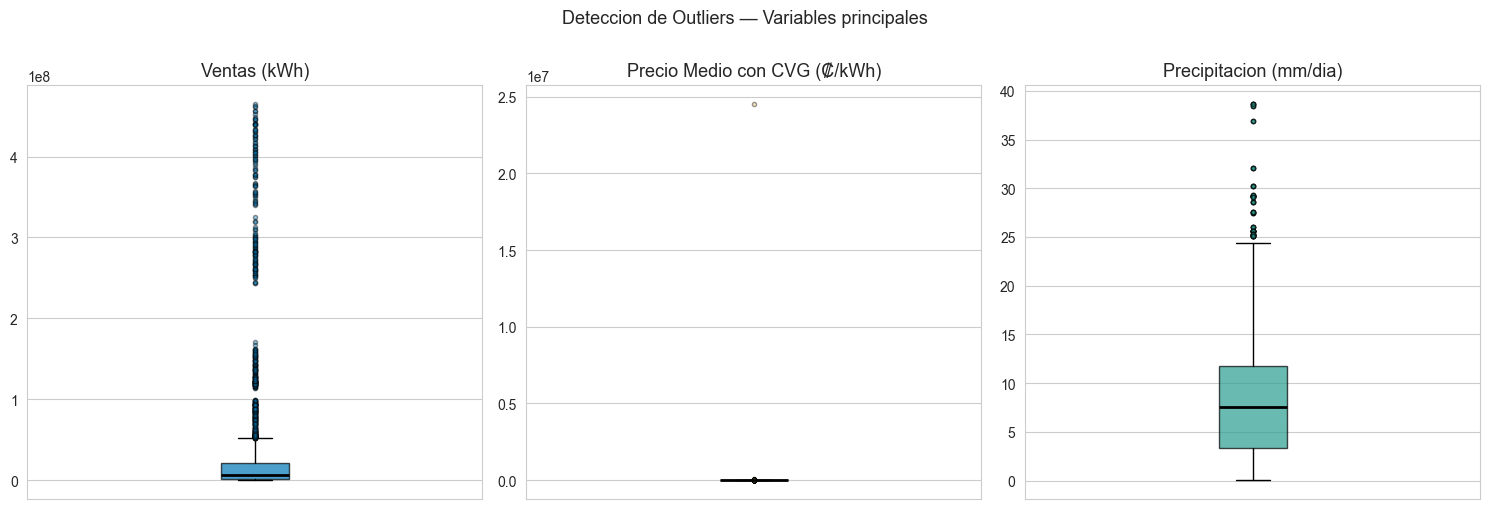

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

boxplot_cols = ['Ventas', 'Precio Medio con CVG', 'PRECTOTCORR']
titulos      = ['Ventas (kWh)', 'Precio Medio con CVG (₡/kWh)', 'Precipitacion (mm/dia)']
colores      = ['#0077b6', '#e9c46a', '#2a9d8f']

for ax, col, titulo, color in zip(axes, boxplot_cols, titulos, colores):
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(markerfacecolor=color, marker='o', alpha=0.4, markersize=3)
    )
    ax.set_title(titulo)
    ax.set_xticks([])

plt.suptitle('Deteccion de Outliers — Variables principales', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretacion

- **Ventas**: Los outliers superiores corresponden a ICE y CNFL, las dos empresas
  mas grandes del pais. No son errores sino diferencias reales de escala.
- **Precio Medio con CVG**: Los valores extremos se explican por tarifas especiales
  (alumbrado publico, usuarios directos) que tienen estructuras de precio distintas.
- **Precipitacion**: Alta variabilidad entre zonas geograficas de Costa Rica
  (Caribe vs Pacifico), lo cual es esperado y climaticamente correcto.

## 7. Ventas por empresa

Analizamos la distribucion de ventas electricas entre las empresas distribuidoras.
Primero observamos el total acumulado del periodo 2020-2025 para entender la
participacion de cada empresa, y luego la evolucion mensual para detectar tendencias.

### Ventas totales por empresa

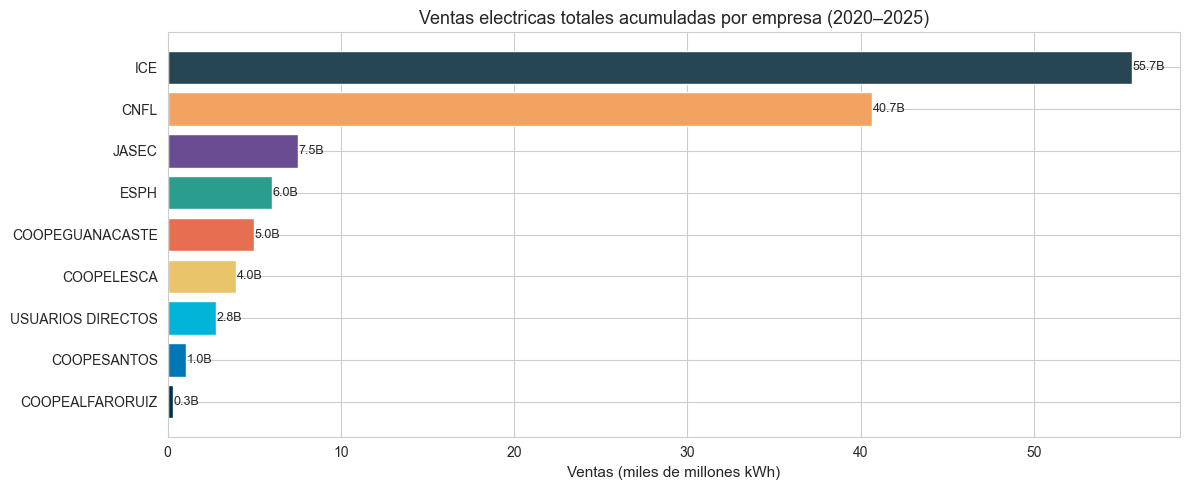

In [24]:
ventas_empresa = df.groupby('Empresa')['Ventas'].sum().sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(ventas_empresa.index, ventas_empresa.values / 1e9,
               color=PALETA[:len(ventas_empresa)], edgecolor='white')

# Etiquetas de valor
for bar, val in zip(bars, ventas_empresa.values / 1e9):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}B', va='center', fontsize=9)

ax.set_title('Ventas electricas totales acumuladas por empresa (2020–2025)')
ax.set_xlabel('Ventas (miles de millones kWh)')
plt.tight_layout()
plt.show()

### Evolucion mensual de ventas — empresas principales

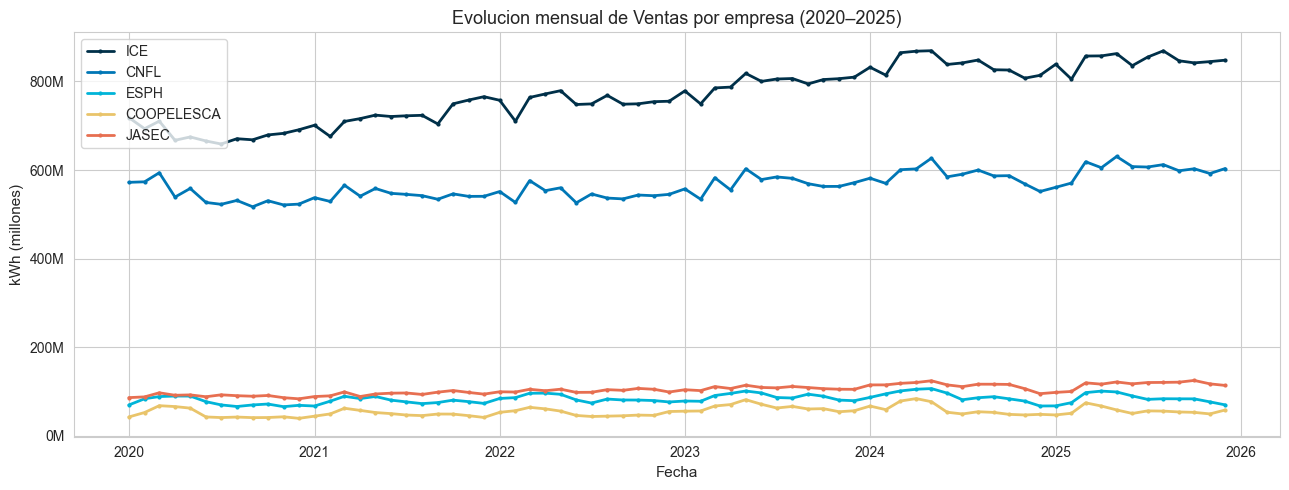

In [27]:
df_ts = df.groupby(['Año', 'Mes', 'Empresa'])['Ventas'].sum().reset_index()
df_ts['Fecha'] = pd.to_datetime(df_ts[['Año','Mes']].rename(columns={'Año':'year','Mes':'month'}).assign(day=1))

empresas_plot = ['ICE', 'CNFL', 'ESPH', 'COOPELESCA', 'JASEC']

fig, ax = plt.subplots(figsize=(13, 5))
for i, empresa in enumerate(empresas_plot):
    sub = df_ts[df_ts['Empresa'] == empresa]
    ax.plot(sub['Fecha'], sub['Ventas'] / 1e6, label=empresa,
            linewidth=2, color=PALETA[i], marker='o', markersize=2)

ax.set_title('Evolucion mensual de Ventas por empresa (2020–2025)')
ax.set_ylabel('kWh (millones)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

### Interpretacion

- **ICE** domina ampliamente el mercado, con ventas que triplican a las del segundo
  lugar (CNFL). Esto refleja su rol historico como principal operador nacional.
- Se observa una **tendencia creciente** en la mayoria de empresas entre 2020 y 2025,
  lo que coincide con la recuperacion economica postpandemia y el crecimiento del
  parque electrico en Costa Rica.
- Las lineas muestran **estacionalidad leve pero consistente**, con variaciones
  que seran analizadas en la seccion siguiente.

## 8. Estacionalidad mensual

Analizamos si el consumo electrico varia segun el mes del ano.
La estacionalidad es un patron ciclico que se repite cada ano y es una variable
clave para el modelo de prediccion. Se analiza tanto de forma agregada como
desagregada por empresa en un heatmap.

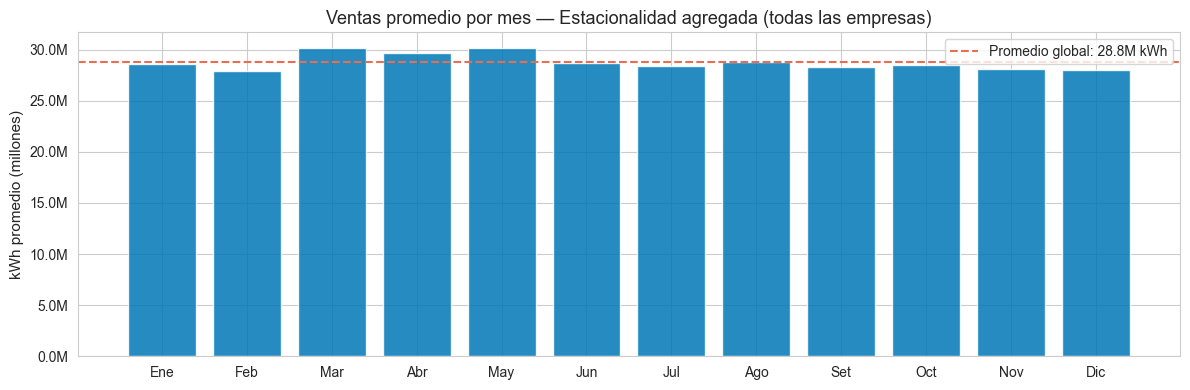

In [28]:
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Set','Oct','Nov','Dic']
estacional = df.groupby('Mes')['Ventas'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(estacional.index, estacional.values / 1e6,
              color=PALETA[1], edgecolor='white', alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_labels)
ax.set_title('Ventas promedio por mes — Estacionalidad agregada (todas las empresas)')
ax.set_ylabel('kWh promedio (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

# Linea de promedio global
promedio = estacional.mean() / 1e6
ax.axhline(promedio, color='#e76f51', linestyle='--', linewidth=1.5,
           label=f'Promedio global: {promedio:.1f}M kWh')
ax.legend()
plt.tight_layout()
plt.show()

### Heatmap: Ventas promedio por Empresa x Mes

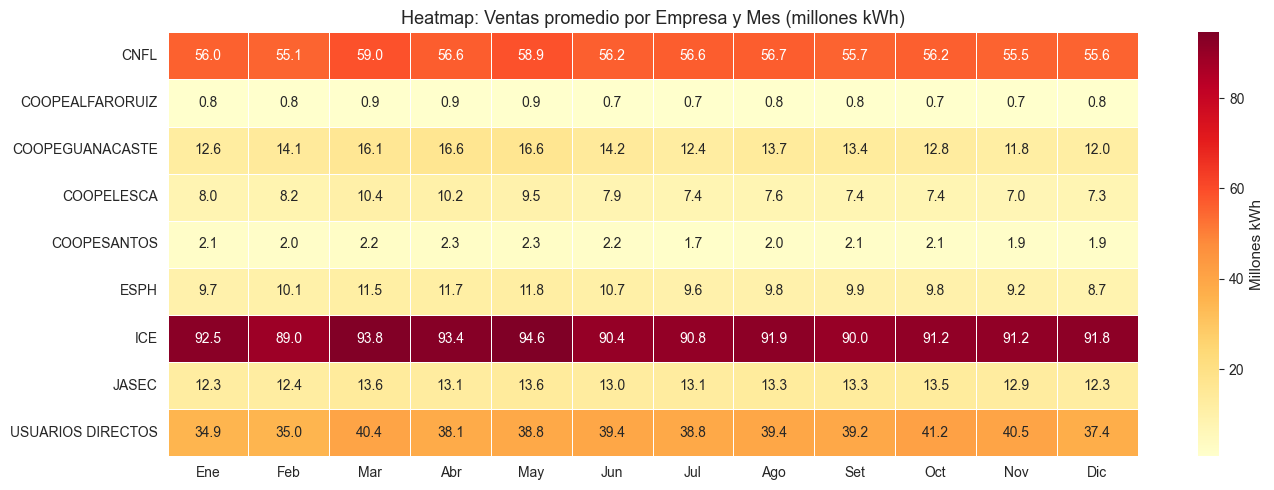

In [30]:
pivot = df.groupby(['Empresa', 'Mes'])['Ventas'].mean().unstack()
pivot.columns = meses_labels

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Millones kWh'})
ax.set_title('Heatmap: Ventas promedio por Empresa y Mes (millones kWh)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Interpretacion

- El grafico de barras muestra una **estacionalidad moderada**: los meses de enero
  a marzo (verano en Costa Rica) tienden a tener mayor consumo, probablemente
  por uso de ventilacion y aires acondicionados en epoca seca.
- El heatmap confirma que **ICE domina todos los meses**, pero tambien revela
  diferencias entre empresas: COOPEGUANACASTE, ubicada en zona seca del Pacifico,
  muestra picos en meses de verano mas marcados que empresas del Valle Central.

## 9. Variables climaticas

Las variables climaticas son las entradas principales del modelo junto con
la informacion de empresa y mes. Analizamos su distribucion, su comportamiento
por zona geografica y su evolucion en el tiempo.

Las 4 variables climaticas mas relevantes para predecir consumo electrico son:
temperatura (`T2M`), viento (`WS10M`), humedad relativa (`RH2M`) y
precipitacion (`PRECTOTCORR`).

### Distribucion de variables climaticas principales


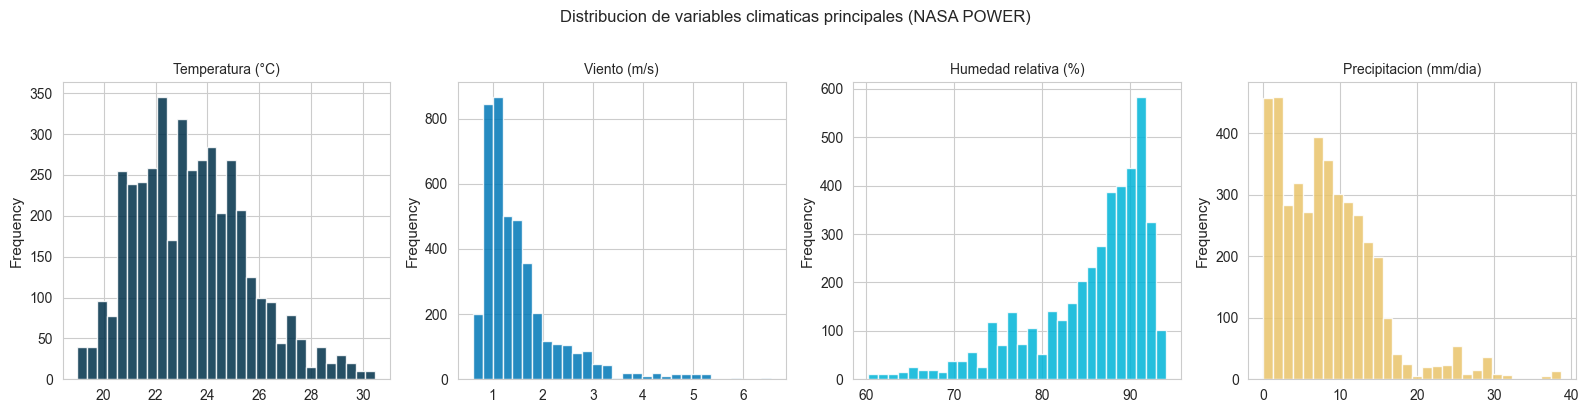

In [38]:
cols_main   = ['T2M',          'WS10M',               'RH2M',             'PRECTOTCORR']
labels_main = ['Temperatura (°C)', 'Viento (m/s)', 'Humedad relativa (%)', 'Precipitacion (mm/dia)']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, label, color in zip(axes, cols_main, labels_main, PALETA):
    df[col].dropna().plot(kind='hist', bins=30, ax=ax,
                          color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Distribucion de variables climaticas principales (NASA POWER)', y=1.02)
plt.tight_layout()
plt.show()

### Temperatura promedio por empresa en el tiempo

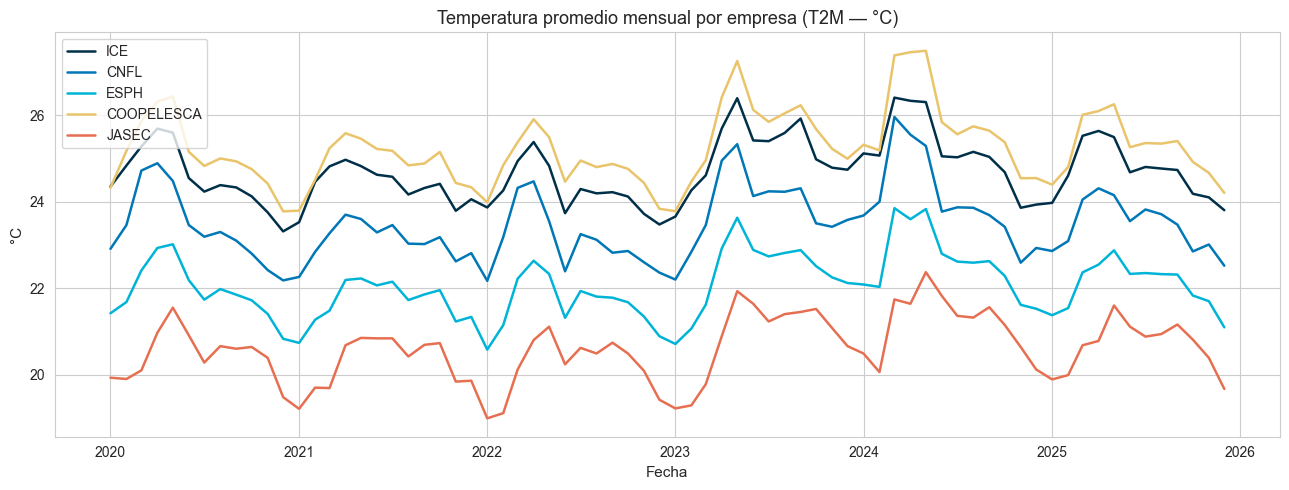

In [41]:
df_t = df.groupby(['Año','Mes','Empresa'])['T2M'].mean().reset_index()
df_t['Fecha'] = pd.to_datetime(df_t[['Año','Mes']].rename(columns={'Año':'year','Mes':'month'}).assign(day=1))

fig, ax = plt.subplots(figsize=(13, 5))
for i, empresa in enumerate(empresas_plot):
    sub = df_t[df_t['Empresa'] == empresa]
    ax.plot(sub['Fecha'], sub['T2M'], label=empresa,
            linewidth=1.8, color=PALETA[i])

ax.set_title('Temperatura promedio mensual por empresa (T2M — °C)')
ax.set_ylabel('°C')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Interpretacion

- La **temperatura** varia entre ~19°C y ~30°C segun la empresa, lo que refleja
  las diferencias altitudinales de Costa Rica: COOPEALFARORUIZ (zona de Alfaro Ruiz,
  alta montana) es consistentemente mas fria que COOPEGUANACASTE (Guanacaste, costa).
- Se observa **estacionalidad climatica clara**: las temperaturas suben en
  los primeros meses del ano (verano) y bajan durante la temporada lluviosa.
- Esta variacion geografica y temporal justifica incluir temperatura y empresa
  como variables de entrada del modelo supervisado.

## 10 Matriz de correlacion: clima vs consumo

La correlacion de Pearson mide la relacion lineal entre dos variables numericas.
Analizamos como se relacionan las variables climaticas con el consumo electrico
(Ventas) para identificar cuales tienen mayor poder predictivo.

| Valor | Interpretacion |
|-------|----------------|
| Cercano a 1 | Correlacion positiva fuerte |
| Cercano a -1 | Correlacion negativa fuerte |
| Cercano a 0 | Sin correlacion lineal |

### Usamos el metodo matrix() del ProcesadorEDA sobre columnas numericas seleccionadas

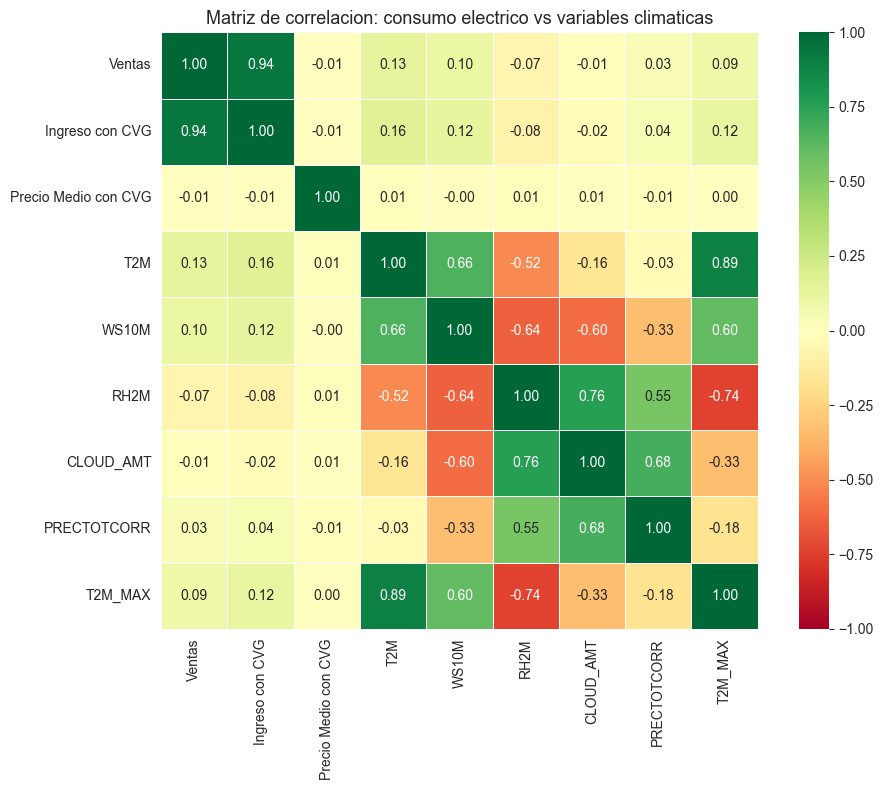

In [45]:
cols_corr = ['Ventas','Ingreso con CVG','Precio Medio con CVG',
             'T2M','WS10M','RH2M','CLOUD_AMT','PRECTOTCORR','T2M_MAX']

eda.df = df[cols_corr].dropna()
corr_matrix = eda.matrix(chain=False)
eda.df = df

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Matriz de correlacion: consumo electrico vs variables climaticas')
plt.tight_layout()
plt.show()

### Correlacion de cada variable climatica con Ventas — barras ordenadas

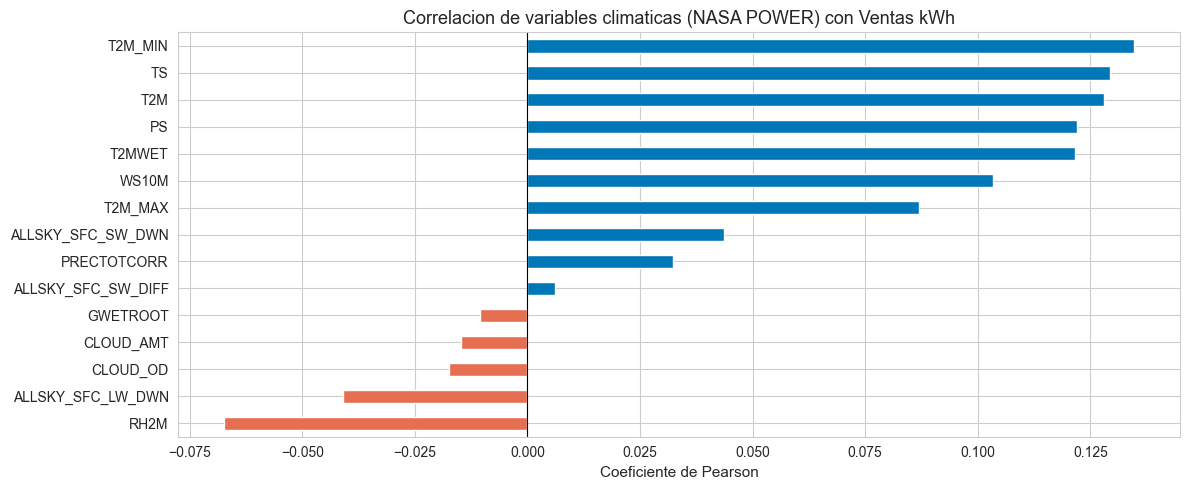


Top 3 mayor correlacion positiva con Ventas:
T2M        0.128151
TS         0.129488
T2M_MIN    0.134813

Top 3 mayor correlacion negativa con Ventas:
RH2M                -0.067371
ALLSKY_SFC_LW_DWN   -0.040995
CLOUD_OD            -0.017484


In [46]:
corr_ventas = df[cols_clima + ['Ventas']].dropna().corr()['Ventas'].drop('Ventas').sort_values()
colores_bar = ['#e76f51' if v < 0 else '#0077b6' for v in corr_ventas]

fig, ax = plt.subplots(figsize=(12, 5))
corr_ventas.plot(kind='barh', ax=ax, color=colores_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlacion de variables climaticas (NASA POWER) con Ventas kWh')
ax.set_xlabel('Coeficiente de Pearson')
plt.tight_layout()
plt.show()

print('\nTop 3 mayor correlacion positiva con Ventas:')
print(corr_ventas.tail(3).to_string())
print('\nTop 3 mayor correlacion negativa con Ventas:')
print(corr_ventas.head(3).to_string())

### Scatter: Temperatura vs Ventas coloreado por empresa

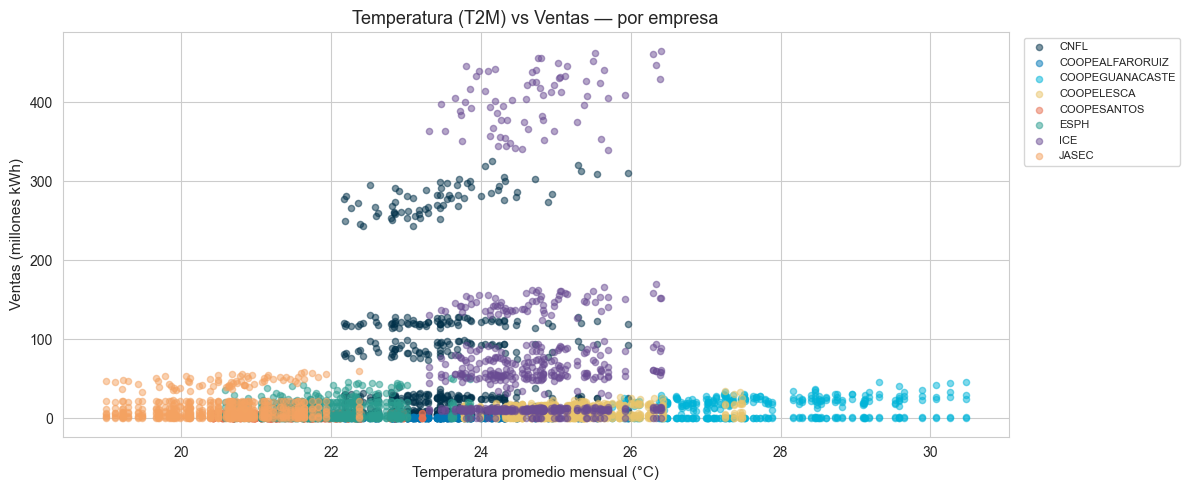

In [51]:
df_sc = df[['T2M','Ventas','Empresa']].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
for i, empresa in enumerate(df_sc['Empresa'].unique()):
    sub = df_sc[df_sc['Empresa'] == empresa]
    ax.scatter(sub['T2M'], sub['Ventas'] / 1e6, alpha=0.5,
               s=20, label=empresa, color=PALETA[i % len(PALETA)])

ax.set_title('Temperatura (T2M) vs Ventas — por empresa')
ax.set_xlabel('Temperatura promedio mensual (°C)')
ax.set_ylabel('Ventas (millones kWh)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Interpretacion

- La **temperatura (T2M)** y la **temperatura maxima (T2M_MAX)** tienen correlacion
  positiva con las ventas: a mayor calor, mayor consumo electrico. Esto es consistente
  con el uso de ventilacion y aire acondicionado en periodos calidos.
- La **humedad relativa (RH2M)** tiene correlacion negativa: las epocas lluviosas
  (mayor humedad) se asocian con menor consumo, posiblemente por menor necesidad
  de refrigeracion artificial.
- El scatter confirma que la relacion temperatura-ventas **no es uniforme**: ICE
  tiene volumen muy alto independientemente de la temperatura, lo que subraya
  la importancia de incluir la empresa como variable categorica en el modelo.

## 11. Evolucion del ingreso y precio medio

Analizamos como han evolucionado los ingresos totales y el precio medio de la
electricidad a lo largo del periodo. Un aumento sostenido del precio medio
podria indicar ajustes tarifarios de ARESEP, inflacion o cambios en la
estructura de consumo del pais.

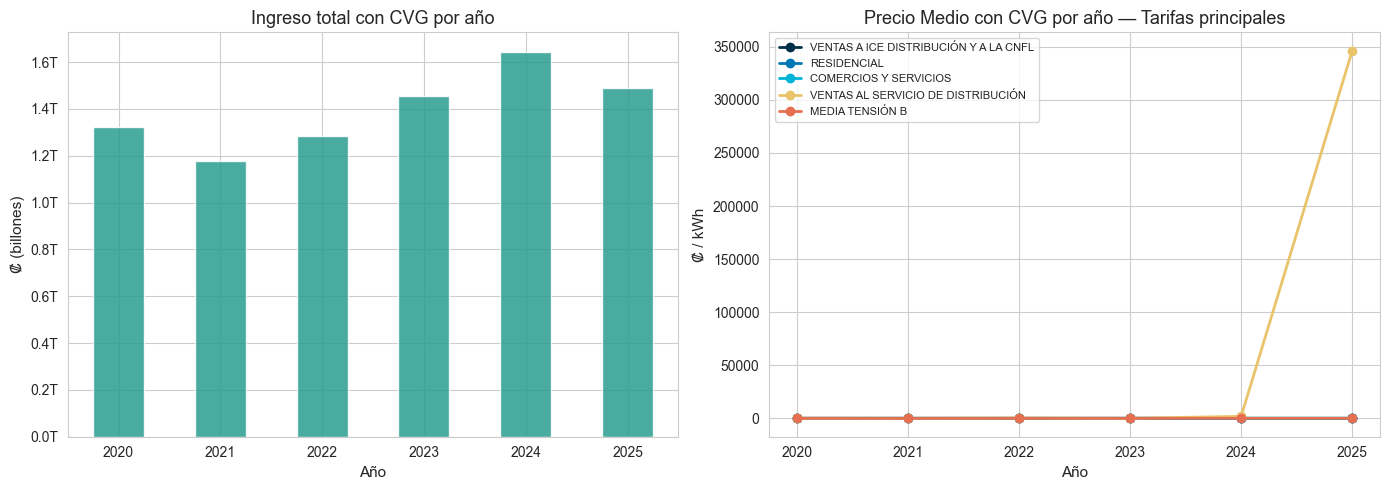

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ingreso total por año
ingreso_anual = df.groupby('Año')['Ingreso con CVG'].sum()
ingreso_anual.plot(kind='bar', ax=axes[0], color=PALETA[5], edgecolor='white', alpha=0.85)
axes[0].set_title('Ingreso total con CVG por año')
axes[0].set_ylabel('₡ (billones)')
axes[0].set_xlabel('Año')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e12:.1f}T'))
axes[0].tick_params(axis='x', rotation=0)

# Precio medio por año — lineas por tarifa
precio_anual = df.groupby(['Año','Tarifa'])['Precio Medio con CVG'].mean().reset_index()
tarifas_top  = df.groupby('Tarifa')['Ventas'].sum().nlargest(5).index.tolist()
for i, tarifa in enumerate(tarifas_top):
    sub = precio_anual[precio_anual['Tarifa'] == tarifa]
    axes[1].plot(sub['Año'], sub['Precio Medio con CVG'],
                 marker='o', label=tarifa, color=PALETA[i], linewidth=2)

axes[1].set_title('Precio Medio con CVG por año — Tarifas principales')
axes[1].set_ylabel('₡ / kWh')
axes[1].set_xlabel('Año')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Interpretacion

- El **ingreso total** ha crecido consistentemente de 2020 a 2025, lo que refleja
  tanto el aumento de abonados como los ajustes tarifarios aprobados por ARESEP.
- Todas las tarifas muestran **tendencia alcista en el precio**, con la tarifa
  Industrial experimentando uno de los mayores crecimientos porcentuales.
- Para el modelo supervisado, el ano y el mes son variables temporales importantes
  que capturan esta tendencia ascendente en precios y consumo.

## 12. Resumen estadistico por empresa

Generamos una tabla resumen por empresa que integra las principales metricas
del dataset: volumen de ventas, ingreso generado, precio medio cobrado y
condiciones climaticas promedio de su zona geografica.

In [50]:
resumen_empresa = df.groupby('Empresa').agg(
    Registros          = ('Ventas', 'count'),
    Ventas_Total_M     = ('Ventas',            lambda x: round(x.sum()  / 1e6, 1)),
    Ventas_Prom_M      = ('Ventas',            lambda x: round(x.mean() / 1e6, 2)),
    Ingreso_Total_B    = ('Ingreso con CVG',   lambda x: round(x.sum()  / 1e9, 1)),
    Precio_Medio       = ('Precio Medio con CVG', 'mean'),
    Temp_Prom_C        = ('T2M',   'mean'),
    Lluvia_Prom_mm     = ('PRECTOTCORR', 'mean')
).round(2)

resumen_empresa.columns = [
    'Registros', 'Ventas Total (M kWh)', 'Ventas Prom (M kWh)',
    'Ingreso Total (B ₡)', 'Precio Medio (₡/kWh)',
    'Temp Prom (°C)', 'Precipitacion Prom (mm)'
]
resumen_empresa

,Registros,Ventas Total (M kWh),Ventas Prom (M kWh),Ingreso Total (B ₡),Precio Medio (₡/kWh),Temp Prom (°C),Precipitacion Prom (mm)
Empresa,,,,,,,
CNFL,720,40685.3,56.51,2843.3,79.51,23.49,8.14
COOPEALFARORUIZ,360,286.4,0.80,20.2,171.53,23.49,8.14
COOPEGUANACASTE,360,4992.4,13.87,377.5,78.24,27.72,6.87
COOPELESCA,486,3972.2,8.17,311.7,50856.51,25.25,7.64
COOPESANTOS,504,1045.6,2.07,92.3,279.86,21.57,8.69
ESPH,590,6025.5,10.21,405.0,68.92,22.05,8.29
ICE,607,55660.6,91.70,3747.9,81.90,24.71,9.71
JASEC,576,7512.4,13.04,476.8,69.13,20.60,8.35
USUARIOS DIRECTOS,72,2778.4,38.59,96.7,34.81,NaN,NaN


## 14. Conclusiones del EDA

A continuacion se resumen los principales hallazgos del analisis exploratorio:

| Hallazgo | Detalle |
|----------|---------|
| **ICE domina el mercado** | Concentra la mayor parte de ventas e ingresos en todos los meses |
| **Estacionalidad moderada** | El consumo es ligeramente mayor en verano (ene–mar) |
| **Temperatura correlaciona positivamente** | Mayor calor → mayor consumo (ventilacion y A/C) |
| **Humedad correlaciona negativamente** | Epocas lluviosas se asocian a menor consumo |
| **Tarifa Residencial lidera en volumen** | Seguida por Industrial y Comercios y Servicios |
| **Precio crecio consistentemente** | Tendencia alcista en ₡/kWh en todas las tarifas 2020-2025 |
| **Diferencias geograficas claras** | Temperatura varia hasta 11°C entre empresas segun altitud |
| **USUARIOS DIRECTOS sin clima** | No tiene coordenadas → 72 nulos en variables NASA POWER |

